AE 498 Homework 3 - Neural Networks

Amanda Yaklin (yaklin2@illinois.edu)

10/5/2026

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_curve, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from torch.utils.data import TensorDataset, DataLoader
import sys
import torch
import torchvision
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

'''
print('Python:', sys.executable)
print('Python version', sys.version)
print('Torch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
'''

# Setup 
# sklearn code template generated using Gemini
# BTS flight data obtained from December 2025

# 0. Declare global variables
FILENAME = 'C:/Users/Amanda/OneDrive - University of Illinois - Urbana/AE 498/T_ONTIME_REPORTING.csv'
COLUMNS = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK','ARR_TIME_BLK','ARR_DEL15']
SAMPLE_FRACTION = 0.07
TEST_FRACTION = 0.20

# 1. Import flight data
data = pd.read_csv(FILENAME, usecols=COLUMNS)
data = pd.DataFrame(data)
data = data.dropna()
#print(data) #debug
# Only use a sample of the available data (to reduce runtime) 
sampled_data = data.sample(frac=SAMPLE_FRACTION, random_state=1)

y = sampled_data['ARR_DEL15']
X = sampled_data.drop(columns=['ARR_DEL15'])
#print(y) #debug

# About 27% of flights are delayed. I will weight the classes accordingly
positive_weight = torch.tensor(np.sum(y)/(y.shape[0]-np.sum(y)))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_FRACTION, 
                                                    random_state=1)
print('test',X_test.shape) #debug
print('train',X_train.shape)
# 2. Select columns to preprocess
categorical_cols = COLUMNS[:-1]

# 3. Create preprocessor for categorical data
# drop='first' prevents multicollinearity 
# (linearly dependent predictors produce a model with infinite possible solutions)
encoder = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_cols)
    ]
)

def auc(X_test, y_test, model_pipeline, dx = 0.01, plot=False):
    # Obtain ROC curve and area under curve (AUC)
    y_scores = model_pipeline.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    auc = np.trapezoid(tpr, fpr, dx=dx)
    print('area under curve    ', auc)
    if plot:
        fig = plt.figure(figsize=[4,4])
        plt.plot(fpr,tpr)
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.title('Receiver Operating Characteristic Curve')

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np


print('setup complete')




test (8007, 5)
train (32028, 5)
setup complete


              precision    recall  f1-score   support

     delayed       0.73      0.99      0.84      5827
     on-time       0.40      0.02      0.04      2180

    accuracy                           0.72      8007
   macro avg       0.56      0.50      0.44      8007
weighted avg       0.64      0.72      0.62      8007

error rate     0.2750093668040464
area under curve     0.6048266295936505


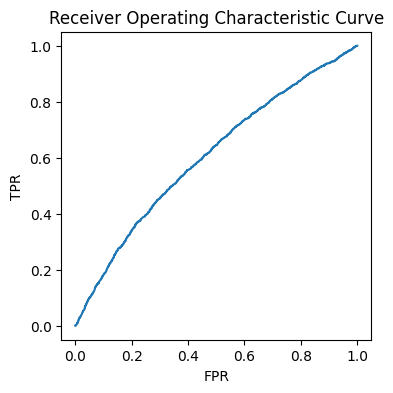

In [57]:
# Part A: Logistic Regression (similar to HW2)
# sklearn code template generated using Gemini
# BTS data obtained from December 2025

# 4. Chain the preprocessor and model into a single Pipeline
# solver='liblinear' fixes sklearn error: 'str' has no attribute 'decode'
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# 5. Fit the entire pipeline on training data
model_pipeline.fit(X_train, y_train)

# 6. Basic prediction evaluation
# precision:
# of all positive predictions, how many were true positive
# = true positive rate / (true positive rate + false positive rate)

# recall:
# of all actual positives in the data, how many were correctly predicted
# actual positives = true positives + false negatives
# = true positive rate / (true positive rate + false negative rate)

# f1 score:
# combine precision and recall metrics to obtain more comprehensive result
# = 2*precision*recall/(precision+recall)
y_pred = model_pipeline.predict(X_test)
target_names = ['delayed','on-time']
print(classification_report(y_test, y_pred,target_names=target_names))

# 7. Obtain error rate
accuracy = accuracy_score(y_test,y_pred)
error_rate = 1 - accuracy
print('error rate    ', error_rate)

# 8. Obtain AUC
auc(X_test, y_test, model_pipeline, plot=True)



preprocessor x train (32028, 712)
preprocessor x test (8007, 712)
input size 712
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.]])
final value of loss 0.2956888864198923


Text(0, 0.5, 'Loss function')

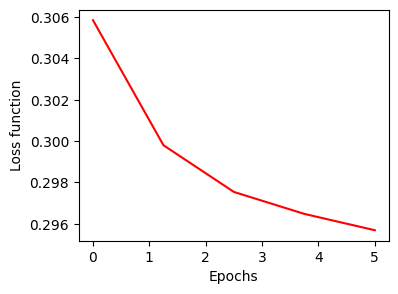

In [58]:
# Part B: Neural Net Training
# Input: One-hot encoded categorical data
# Output: 1 output (flight delayed 15 mins, yes/no)
# Net structure: Linear layers

# Parameters to tune

# Learning rate ~ how much the parameter weights can change per epoch 
#   Higher values can produce results faster and less accurately
#   Lower values can produce results more slowly and can get stuck with high error
learning_rate = 0.05 

# Layer sizes ~ dimensions of weighting matrices
#    Larger values can produce overfitting; smaller values may produce underfitting
layer_sizes = [120,64]

# Epochs ~ number of iterations for the training loop 
#   Larger values can produce overfitting; smaller values can produce underfitting
epochs = 5

# Batch size ~ no. of samples to use in each training step
batch_size = 10

# Store preprocessed data
encoder = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_cols)
    ]
)
# Fit to training data only
X_train_processed = preprocessor.fit_transform(X_train)
# Transform test data using learned categories 
# (Don't use fit_transform here -- it will create a mismatch in parameter count!)
X_test_processed = preprocessor.transform(X_test)

print('preprocessor x train', X_train_processed.shape)
print('preprocessor x test', X_test_processed.shape)

input_size = X_train_processed.shape[1]
print('input size', input_size)

# Define neural net 
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(input_size, layer_sizes[0]) # Linear layer 1
        self.fc2 = nn.Linear(layer_sizes[0], layer_sizes[1]) # Linear layer 2
        self.output = nn.Linear(layer_sizes[1],1) # Output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.output(x)
        return x


#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu') # CUDA wasn't faster
net = Net().to(device)
params = net.parameters()
net.zero_grad() # Zero the gradient buffers

# Define loss-function criterion
# Binary cross-entropy (used for binary classification)
# BCE provides strong penalization of incorrect predictions
# WithLogits is used to incorporate sigmoid = nn.Sigmoid() and improve numerical stability
criterion = nn.BCEWithLogitsLoss(pos_weight = positive_weight) 

# Train model (non-deterministic)

# Convert sparse matrices to dense matrices
X_train_tensor = torch.from_numpy(X_train_processed.toarray()).float()
X_test_tensor = torch.from_numpy(X_test_processed.toarray()).float()
print(X_train_tensor)

# Convert outputs to tensor
y_train_tensor = torch.from_numpy(y_train.values).float()
y_test_tensor = torch.from_numpy(y_test.values).float()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

net.train()
optimizer = optim.SGD(params, lr=learning_rate)
losses = []
for epoch in range(epochs):
    running_loss = 0.0
    count = 0.0
    for data in train_loader:
        X_t, y_t = data
        X_t = X_t.to(device)
        y_t = y_t.to(device)
        count += 1
        output = net(X_t)
        loss = criterion(output, y_t.unsqueeze(1)) # Calculate loss
        running_loss += loss.item()
        # Backward step
        optimizer.zero_grad() # Zero to avoid gradient accumulation
        loss.backward() # New gradients add to existing gradients
        optimizer.step()
    losses.append(running_loss/count) 

print('final value of loss', losses[-1])
ep = np.linspace(0,epochs,epochs)
fig = plt.figure(figsize=[4,3])
plt.plot(ep, losses, color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss function')

In [59]:
# Save model
path = './bts_nn.pt'
torch.save(net.state_dict(), path)

In [65]:
# Test model using test data
correct = 0
total = 0

net.eval()
with torch.no_grad():
    for data in test_loader:
        Xtest, ytest = data
        Xtest = Xtest.to(device)
        ytest = ytest.to(device)
        outputs = net(Xtest)
        predicted = (torch.sigmoid(outputs)>0.5).squeeze()
        total += ytest.size(0)
        correct += (predicted == ytest).sum().item()
print(correct)      
net_accuracy = 100*correct//total

print(f'Accuracy of network on {X_test_processed.shape[0]} test flights: {net_accuracy}%') 
        

5827
Accuracy of network on 8007 test flights: 72%


In [ ]:
# Test model using some user input row
flight_data_user = ['AA','PHX','PIT','0001-0559','0900-0959']

# Process given row into a suitable net input
inp = {}
for i in range(len(COLUMNS)-1):
    inp[COLUMNS[i]] = [flight_data_user[i]]
df = pd.DataFrame.from_dict(inp)
df_processed = preprocessor.transform(df)
df_tensor = torch.from_numpy(df_processed.toarray()).float()
output = net(df_tensor)

prediction = torch.sigmoid(output).item() # Convert output to probability
prediction = np.round(prediction, 3)
print(f'There is a {prediction*100}% chance that this flight is 15 minutes delayed on arrival')

There is a 31.0% chance that this flight is 15 minutes delayed on arrival


Discussion:

The neural net uses 2 linear layers to model the flight delay as a function of 5 input parameters (unique carrier, origin airport, destination airport, departure time block, and arrival time block). Since about 72% of flights are on-time (class 0), prediction accuracy of 72% is roughly equivalent to the accuracy of the model if it predicted 0 for all inputs. With weighting applied to the binary cross-entropy criterion, the loss function was decreased from 0.59 at 5 epochs to 0.29, but since model is severely biased against positive predictions, the accuracy remained stuck at 72%. When the threshold (0.5) in predicted = (torch.sigmoid(outputs)>0.5).squeeze() is adjusted downward, the accuracy only decreases from 72%. Increasing the number of epochs also does not improve accuracy. Below, I have checked the mean feature values for the test data, which confirms that the parameter space provides insufficient prediction capability. This was also demonstrated in the logistic regression exercise, which predicted a close-to-random model with AUC ~ 0.6. Thus, more predictive features are desired (i.e. air traffic, weather conditions, age of aircraft).

In [66]:
# Do delayed flights look different from not-delayed?
X_delayed = X_test_tensor[y_test_tensor == 1]
X_not_delayed = X_test_tensor[y_test_tensor == 0]

print(f"Mean feature values for delayed: {X_delayed.mean(dim=0)[:10]}")
print(f"Mean feature values for not delayed: {X_not_delayed.mean(dim=0)[:10]}")

Mean feature values for delayed: tensor([0.1358, 0.0417, 0.0413, 0.1491, 0.0362, 0.0216, 0.0101, 0.0358, 0.0317,
        0.0459])
Mean feature values for not delayed: tensor([0.1378, 0.0359, 0.0323, 0.1512, 0.0287, 0.0158, 0.0089, 0.0422, 0.0206,
        0.0293])
